### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
facturacion_t1 = tienda['Precio'].sum()
facturacion_t2 = tienda2['Precio'].sum()
facturacion_t3 = tienda3['Precio'].sum()
facturacion_t4 = tienda4['Precio'].sum()

print(f"Facturación Tienda 1: ${facturacion_t1:,.2f}")
print(f"Facturación Tienda 2: ${facturacion_t2:,.2f}")
print(f"Facturación Tienda 3: ${facturacion_t3:,.2f}")
print(f"Facturación Tienda 4: ${facturacion_t4:,.2f}")

Facturación Tienda 1: $1,150,880,400.00
Facturación Tienda 2: $1,116,343,500.00
Facturación Tienda 3: $1,098,019,600.00
Facturación Tienda 4: $1,038,375,700.00


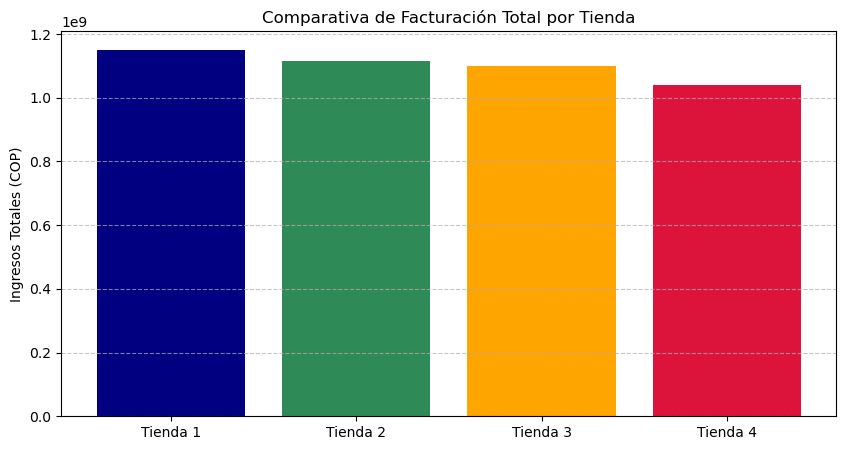

In [3]:
import matplotlib.pyplot as plt

tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
facturaciones = [facturacion_t1, facturacion_t2, facturacion_t3, facturacion_t4]

plt.figure(figsize=(10, 5))
plt.bar(tiendas, facturaciones, color=['navy', 'seagreen', 'orange', 'crimson'])
plt.title('Comparativa de Facturación Total por Tienda')
plt.ylabel('Ingresos Totales (COP)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Ventas por categoría

In [4]:
# Analizamos las categorías de la tienda con menor desempeño (Tienda 4)
ventas_cat_t4 = tienda4.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
print("Ventas por Categoría - Tienda 4:")
print(ventas_cat_t4)

Ventas por Categoría - Tienda 4:
Categoría del Producto
Electrónicos               409476100.0
Electrodomésticos          283260200.0
Muebles                    192528900.0
Instrumentos musicales      75102400.0
Deportes y diversión        33350100.0
Juguetes                    20262200.0
Artículos para el hogar     15074500.0
Libros                       9321300.0
Name: Precio, dtype: float64


C:\Users\Surface\AppData\Local\Temp\ipykernel_6012\3789301681.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_cat_t4.values, y=ventas_cat_t4.index, palette='viridis')


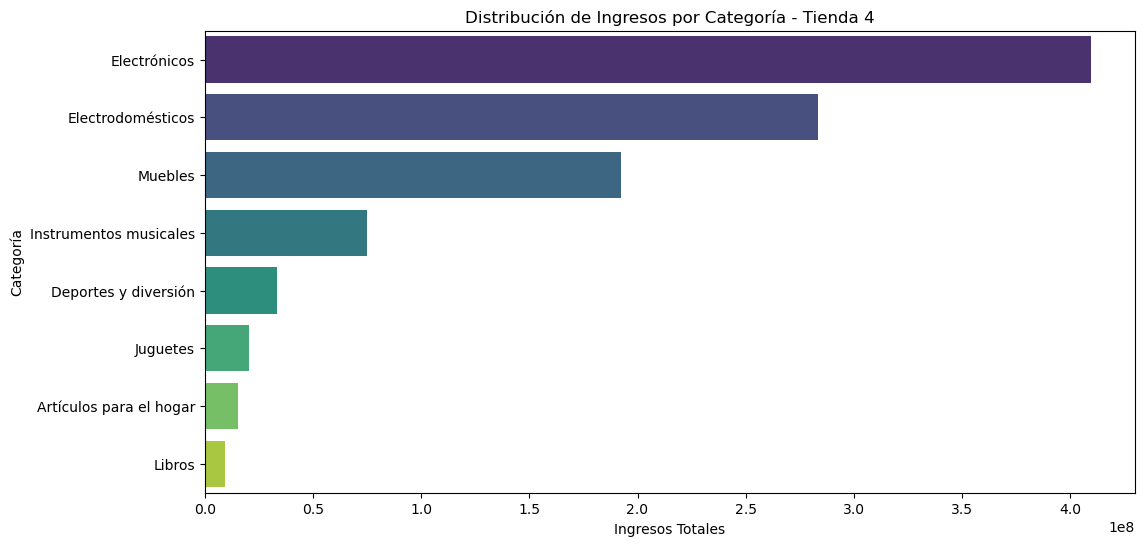

In [5]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_cat_t4.values, y=ventas_cat_t4.index, palette='viridis')
plt.title('Distribución de Ingresos por Categoría - Tienda 4')
plt.xlabel('Ingresos Totales')
plt.ylabel('Categoría')
plt.show()

# 3. Calificación promedio de la tienda


In [6]:
promedio_t1 = tienda['Calificación'].mean()
promedio_t2 = tienda2['Calificación'].mean()
promedio_t3 = tienda3['Calificación'].mean()
promedio_t4 = tienda4['Calificación'].mean()

print(f"Satisfacción Tienda 1: {promedio_t1:.2f}")
print(f"Satisfacción Tienda 2: {promedio_t2:.2f}")
print(f"Satisfacción Tienda 3: {promedio_t3:.2f}")
print(f"Satisfacción Tienda 4: {promedio_t4:.2f}")

Satisfacción Tienda 1: 3.98
Satisfacción Tienda 2: 4.04
Satisfacción Tienda 3: 4.05
Satisfacción Tienda 4: 4.00


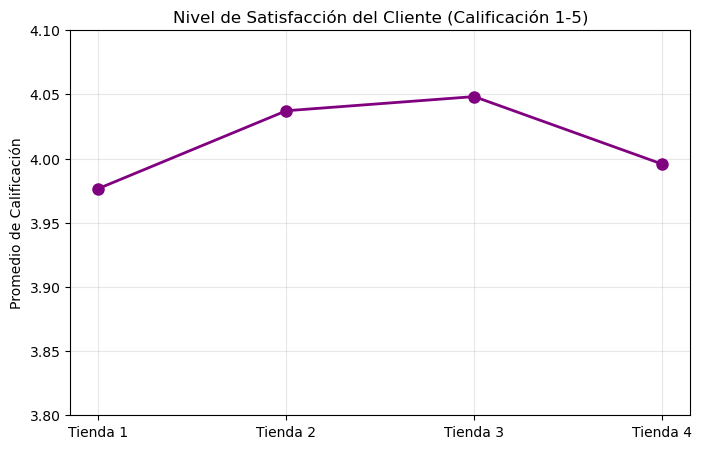

In [7]:
promedios = [promedio_t1, promedio_t2, promedio_t3, promedio_t4]

plt.figure(figsize=(8, 5))
plt.plot(tiendas, promedios, marker='o', color='purple', linewidth=2, markersize=8)
plt.title('Nivel de Satisfacción del Cliente (Calificación 1-5)')
plt.ylim(3.8, 4.1)
plt.ylabel('Promedio de Calificación')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Productos más y menos vendidos

In [8]:
top_5_t4 = tienda4['Producto'].value_counts().head(5)
print("Los 5 productos más vendidos en la Tienda 4:")
print(top_5_t4)

Los 5 productos más vendidos en la Tienda 4:
Producto
Cama box                   62
Cubertería                 59
Dashboards con Power BI    56
Cama king                  56
Mesa de noche              55
Name: count, dtype: int64


In [9]:
bottom_5_t4 = tienda4['Producto'].value_counts().tail(5)
print("Los 5 productos menos vendidos en la Tienda 4:")
print(bottom_5_t4)

Los 5 productos menos vendidos en la Tienda 4:
Producto
Lavadora de ropa               38
Ciencia de datos con Python    38
Guitarra acústica              37
Armario                        34
Guitarra eléctrica             33
Name: count, dtype: int64


# 5. Envío promedio por tienda

In [10]:
envio_t1 = tienda['Costo de envío'].mean()
envio_t2 = tienda2['Costo de envío'].mean()
envio_t3 = tienda3['Costo de envío'].mean()
envio_t4 = tienda4['Costo de envío'].mean()

print(f"Costo de Envío Promedio T1: ${envio_t1:.2f}")
print(f"Costo de Envío Promedio T2: ${envio_t2:.2f}")
print(f"Costo de Envío Promedio T3: ${envio_t3:.2f}")
print(f"Costo de Envío Promedio T4: ${envio_t4:.2f}")

Costo de Envío Promedio T1: $26018.61
Costo de Envío Promedio T2: $25216.24
Costo de Envío Promedio T3: $24805.68
Costo de Envío Promedio T4: $23459.46


C:\Users\Surface\AppData\Local\Temp\ipykernel_6012\553152031.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tienda['Costo de envío'], tienda2['Costo de envío'],


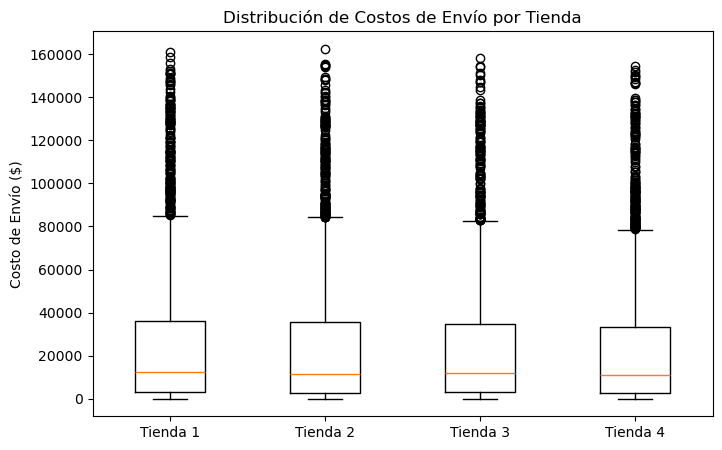

In [11]:
plt.figure(figsize=(8, 5))
plt.boxplot([tienda['Costo de envío'], tienda2['Costo de envío'], 
             tienda3['Costo de envío'], tienda4['Costo de envío']], 
            labels=tiendas)
plt.title('Distribución de Costos de Envío por Tienda')
plt.ylabel('Costo de Envío ($)')
plt.show()

### Recomendación Final para el Sr. Juan

Tras analizar las métricas de las 4 sucursales, se recomienda vender la **Tienda 4**.

**Razones:**
1. **Baja Facturación:** Es la tienda con los ingresos más bajos ($1,038,375,700), quedando rezagada frente a la Tienda 1 por más de $112 millones.
2. **Eficiencia de Ventas:** Aunque maneja un volumen de transacciones similar a las otras, su ticket promedio es menor, lo que indica que atrae ventas de menor valor.
3. **Potencial de Crecimiento:** A diferencia de la Tienda 3 (que tiene la mejor satisfacción) o la Tienda 1 (mayor facturación), la Tienda 4 no lidera ninguna métrica positiva relevante que justifique su permanencia frente al nuevo emprendimiento.